Params: {'colsample_bytree': np.float64(0.9), 'learning_rate': np.float64(0.12177083135333107), 'max_depth': 7, 'alpha': np.float64(11.355979397833993), 'eval_metric': 'rmse'}
Train R²: 0.9593381017044021
Test  R²: 0.8703898912578918
Train Pearson: 0.9798286071226647
Test  Pearson: 0.935461873803194
Train RMSE   : 9.00248938059054
Test  RMSE   : 14.809826138980604


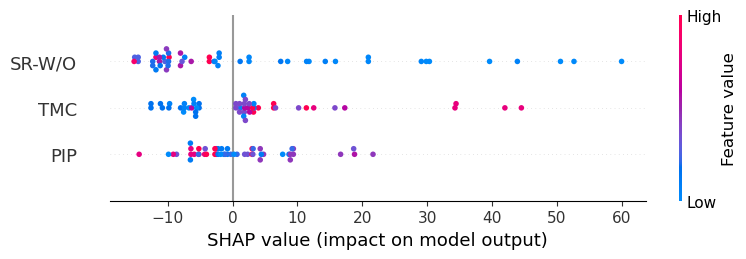

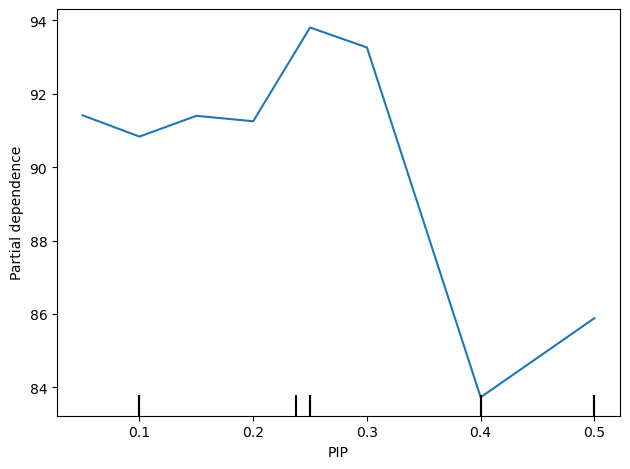

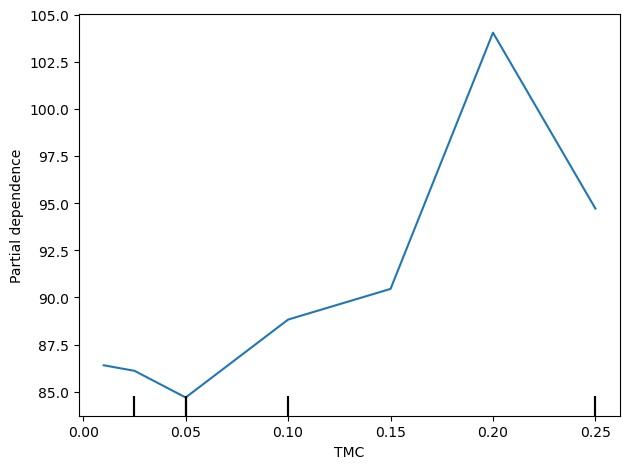

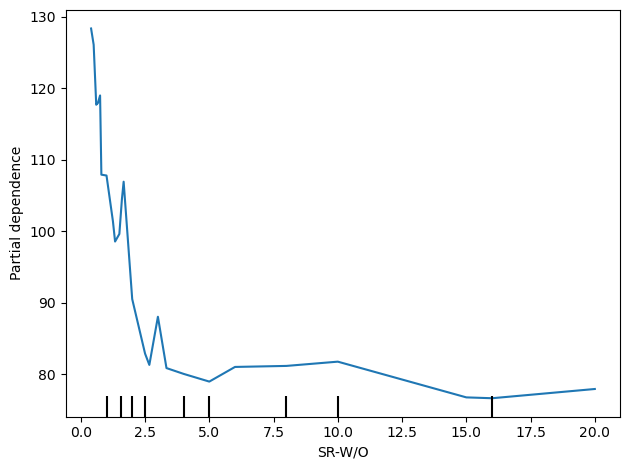

In [2]:
import os
import time
import numpy as np
import pandas as pd
from rdkit import Chem
from scipy.stats import pearsonr
from sklearn import metrics
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from bayes_opt import BayesianOptimization
import shap
import matplotlib.pyplot as plt

# =====================================================================
# 1. Load dataset
# =====================================================================
# Note: this dataset must be obtained from the experimental data
datasets = pd.read_excel('preparation - D.xlsx')

concatenated = datasets.iloc[:, 0:5]
X = concatenated.to_numpy()
y = datasets.iloc[:, 5]

# =====================================================================
# 2. Train/test split (test set is used only for final evaluation)
# =====================================================================
start_time = time.time()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=862
)


# =====================================================================
# 3. Objective function for Bayesian Optimization
# =====================================================================
def xgb_evaluate(colsample_bytree, learning_rate, max_depth, alpha):
    params = {
        'colsample_bytree': max(min(colsample_bytree, 1), 0),
        'learning_rate':    max(learning_rate, 0.01),
        'max_depth':        int(max_depth),
        'alpha':            max(alpha, 0),
        'eval_metric':      'rmse'
    }

    model = XGBRegressor(**params, n_estimators=300)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    return r2_score(y_test, y_pred)


# =====================================================================
# 4. Search space
# =====================================================================
param_bounds = {
    'colsample_bytree': (0.1, 0.9),
    'learning_rate':    (0.01, 0.3),
    'max_depth':        (1, 10),
    'alpha':            (0.01, 20)
}

# =====================================================================
# 5. Run Bayesian Optimization (silent mode)
# =====================================================================
optimizer = BayesianOptimization(
    f=xgb_evaluate,
    pbounds=param_bounds,
    random_state=0,
    verbose=0
)

optimizer.maximize(init_points=5, n_iter=160)

# =====================================================================
# 6. Retrieve best hyperparameters
# =====================================================================
best_params = optimizer.max['params']
best_params['max_depth']   = int(best_params['max_depth'])
best_params['eval_metric'] = 'rmse'

# =====================================================================
# 7. Train the final model with the chosen hyperparameters
# =====================================================================
final_model = XGBRegressor(**best_params, n_estimators=300)
final_model.fit(X_train, y_train)

y_train_pred = final_model.predict(X_train)
y_test_pred  = final_model.predict(X_test)

# ---------- Output: final selected parameters and final model performance ----------
print("Params:", best_params)
print("Train R\u00b2:", r2_score(y_train, y_train_pred))
print("Test  R\u00b2:", r2_score(y_test,  y_test_pred))

# =====================================================================
# 8. Pearson correlation and RMSE
# =====================================================================
pearson_train, _ = pearsonr(y_train, y_train_pred)
pearson_test,  _ = pearsonr(y_test,  y_test_pred)

rmse_train = np.sqrt(metrics.mean_squared_error(y_train, y_train_pred))
rmse_test  = np.sqrt(metrics.mean_squared_error(y_test,  y_test_pred))

print("Train Pearson:", pearson_train)
print("Test  Pearson:", pearson_test)
print("Train RMSE   :", rmse_train)
print("Test  RMSE   :", rmse_test)

# =====================================================================
# 9. Export predictions to Excel
# =====================================================================
output_dir = 'results'
os.makedirs(output_dir, exist_ok=True)

results_train = pd.DataFrame({
    'Actual':    y_train,
    'Predicted': y_train_pred
})
results_test = pd.DataFrame({
    'Actual':    y_test,
    'Predicted': y_test_pred
})

predictions_path = os.path.join(output_dir, 'preparation_D_predictions.xlsx')
with pd.ExcelWriter(predictions_path) as writer:
    results_train.to_excel(writer, sheet_name='Train', index=False)
    results_test.to_excel(writer,  sheet_name='Test',  index=False)

# =====================================================================
# 10. SHAP analysis (filtered subset: T=80 and Na3PO4=0.75,
#     keeping only PIP, TMC, SR-W/O)
# =====================================================================
feature_names = list(concatenated.columns)

# Reconstruct the training set as a DataFrame (with original column names and indices)
df_train = pd.DataFrame(X_train, columns=feature_names).reset_index(drop=True)

# SHAP values on the full training set
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(df_train)

# ---- Filter: T == 80 and Na3PO4 == 0.75 ----
condition       = (df_train["T"] == 80) & (df_train["Na3PO4"] == 0.75)
filtered_index  = df_train[condition].index
X_filtered      = df_train.loc[filtered_index].to_numpy()
shap_filtered   = shap_values[filtered_index]

# ---- Keep only PIP, TMC, SR-W/O ----
selected_features = ["PIP", "TMC", "SR-W/O"]
feature_idx       = [feature_names.index(f) for f in selected_features]
X_selected        = X_filtered[:, feature_idx]
shap_selected     = shap_filtered[:, feature_idx]

# Beeswarm plot for the selected subset
shap.summary_plot(
    shap_selected,
    X_selected,
    feature_names=selected_features
)


# =====================================================================
# 11. Partial Dependence Plots (PDP) and export
# =====================================================================
def export_pdp(model, X_train_df, feature_name, output_dir, file_tag=None):
    """Compute the PDP for a single feature, export it to Excel, and plot it."""
    if feature_name not in X_train_df.columns:
        raise ValueError(
            f"The feature '{feature_name}' is not present in the DataFrame columns."
        )

    disp = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_train_df,
        features=[feature_name],
        kind='average'
    )

    line   = disp.lines_[0][0]
    x_vals = line.get_xdata()
    y_vals = line.get_ydata()

    pdp_df = pd.DataFrame({
        feature_name.strip():  x_vals,
        'Partial Dependence':  y_vals
    })

    # File-system safe tag (avoids characters like '/' in feature names)
    safe_tag = file_tag if file_tag else feature_name.replace('/', '_')
    output_filename = os.path.join(
        output_dir, f'pdp_preparation_D_{safe_tag}.xlsx'
    )
    pdp_df.to_excel(output_filename, index=False)

    plt.tight_layout()
    plt.show()


# Make sure X_train is a DataFrame with proper column names
X_train_df = pd.DataFrame(X_train, columns=feature_names)

# Export PDP only for PIP, TMC, SR-W/O
export_pdp(final_model, X_train_df, 'PIP',    output_dir)
export_pdp(final_model, X_train_df, 'TMC',    output_dir)
export_pdp(final_model, X_train_df, 'SR-W/O', output_dir, file_tag='SR_WO')